In [1]:
# Rebuild the cleaned volunteer data (same 6 people from Build 1)
import pandas as pd
import sqlite3

data = {
    "name":  ["Maria Lopez","James Chen","Aisha Khan","Tom Reed","Priya Patel","David Kim"],
    "email": ["maria@x.com","james@x.com","aisha@x.com","tom@x.com","priya@x.com",""],
    "signup_date": ["2026-06-01","2026-06-02","2026-06-03","2026-06-04","2026-06-06","2026-06-07"],
    "hours": [4, 6, 0, 3, 8, 5],
}
df = pd.DataFrame(data)

# Create a SQL database in memory and load the data into a table called "volunteers"
conn = sqlite3.connect(":memory:")
df.to_sql("volunteers", conn, index=False, if_exists="replace")

print("Loaded", len(df), "volunteers into a SQL database.")

Loaded 6 volunteers into a SQL database.


In [2]:
# QUERY 1: total volunteer hours, and how many volunteers
query1 = """
SELECT COUNT(*) AS total_volunteers,
       SUM(hours) AS total_hours,
       ROUND(AVG(hours), 1) AS avg_hours
FROM volunteers
"""
print("Query 1 — overall summary:")
print(pd.read_sql(query1, conn))
print()

# QUERY 2: hours per person, ranked highest to lowest
query2 = """
SELECT name, hours
FROM volunteers
ORDER BY hours DESC
"""
print("Query 2 — hours per volunteer:")
print(pd.read_sql(query2, conn))

Query 1 — overall summary:
   total_volunteers  total_hours  avg_hours
0                 6           26        4.3

Query 2 — hours per volunteer:
          name  hours
0  Priya Patel      8
1   James Chen      6
2    David Kim      5
3  Maria Lopez      4
4     Tom Reed      3
5   Aisha Khan      0


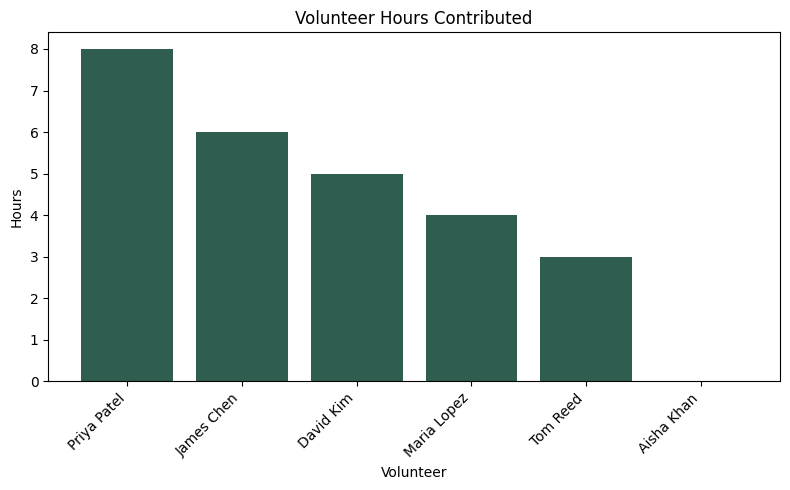

In [3]:
# --- CHART: hours per volunteer ---
import matplotlib.pyplot as plt

# Pull the ranked data from SQL into a dataframe we can chart
chart_data = pd.read_sql(query2, conn)

plt.figure(figsize=(8, 5))
plt.bar(chart_data["name"], chart_data["hours"], color="#2F5D50")
plt.title("Volunteer Hours Contributed")
plt.xlabel("Volunteer")
plt.ylabel("Hours")
plt.xticks(rotation=45, ha="right")   # tilt names so they don't overlap
plt.tight_layout()
plt.savefig("volunteer_hours.png", dpi=150)   # saves the chart as an image
plt.show()

In [4]:
# --- SAVE the SQL queries to a file for the repo ---
sql_text = """-- Query 1: overall summary
SELECT COUNT(*) AS total_volunteers,
       SUM(hours) AS total_hours,
       ROUND(AVG(hours), 1) AS avg_hours
FROM volunteers;

-- Query 2: hours per volunteer, ranked
SELECT name, hours
FROM volunteers
ORDER BY hours DESC;
"""

with open("queries.sql", "w") as f:
    f.write(sql_text)
print("Saved queries.sql")

from google.colab import files
files.download("volunteer_hours.png")   # download the chart
files.download("queries.sql")            # download the SQL file


Saved queries.sql


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>